# 1D Compressible Flow Analysis of a Convergent-Divergent Nozzle

This notebook evaluates the aerodynamic properties of a rocket nozzle assuming 1D isentropic, choked flow. Rather than relying on standard optimization libraries, this solver implements a custom **Newton-Raphson root-finding algorithm** to iteratively evaluate the highly non-linear Area-Mach relation.

## Stagnation Parameters
The stagnation conditions and gas properties feeding the nozzle are defined as:
* Chamber Pressure ($P_c$) = 500 psi
* Chamber Temperature ($T_c$) = 5000 $^\circ$R
* Molecular Weight ($\mathcal{M}$) = 20 lb/lb-mol
* Ratio of Specific Heats ($\gamma$) = 1.2

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Stagnation Conditions and Gas Properties
PC = 500.0          # Chamber pressure [psi]
TC = 5000.0         # Chamber temperature [Rankine]
MOL_WEIGHT = 20.0   # [lb/lb-mol]
GAMMA = 1.2         # Ratio of specific heats
RU = 1545.3         # Universal gas constant [ft-lbf/(lb-mol R)]
R = RU / MOL_WEIGHT # Specific gas constant [ft-lbf/(lb R)]
G = 32.174          # Gravitational acceleration [ft/s^2]

## Nozzle Aerodynamic Contour
The internal aerodynamic contour of the nozzle dictates the expansion ratio and local flow properties. The radial distance $r$ to the nozzle wall as a function of axial distance $x$ from the throat ($|x| \le 10$) is mathematically defined by the polynomial[cite: 28]:

$$r(x) = 1 + 0.435|x| - 0.00365x^2 - 0.000659|x|^3$$

In [2]:
def get_radius(x):
    """Calculates nozzle radius 'r' in inches for a given axial position 'x'"""
    return 1.0 + 0.435*np.abs(x) - 0.00365*(np.abs(x)**2) - 0.000659*(np.abs(x)**3)

## Numerical Method: Area-Mach Relation
For choked, isentropic flow, the local Mach number $M$ is coupled to the local area ratio $A/A^*$ via the non-linear relation:

$$\left(\frac{A}{A^*}\right)^2 = \frac{1}{M^2} \left[ \frac{2}{\gamma+1} \left( 1 + \frac{\gamma-1}{2} M^2 \right) \right]^{\frac{\gamma+1}{\gamma-1}}$$

To resolve $M$ at each spatial coordinate, we define an objective function $F(M) - \left(\frac{A}{A^*}\right)^2 = 0$ and utilize Newton's method to iteratively update the Mach number guess based on the function's analytical derivative until convergence is achieved.

In [3]:
def solve_mach_from_area_ratio(area_ratio, gamma, supersonic=True, tol=1e-8, max_iter=50):
    """Solves the Area-Mach relation for Mach number using Newton's method."""
    if area_ratio < 1.0: return np.nan
    if area_ratio == 1.0: return 1.0

    C = area_ratio**2
    gp1 = gamma + 1
    gm1 = gamma - 1

    # Initial guess for Mach number
    if supersonic:
        M = 1.0 + 2.0 * (area_ratio - 1)**0.5
    else:
        M = 0.5 * area_ratio**(-0.5)

    # Newton-Raphson iteration
    for _ in range(max_iter):
        # Calculate the function F(M)
        F_M = (1/M**2) * ((2/gp1) * (1 + (gm1/2)*M**2))**(gp1/gm1)

        # Calculate the derivative of F(M)
        dg = F_M * (2*(M**2 - 1)) / (M * (1 + (gm1/2)*M**2))

        g = F_M - C

        if abs(g) < tol:
            return M

        if abs(dg) < 1e-12: # Avoid division by zero
            break

        # Newton's method step
        M_new = M - g/dg
        if M_new < 0:
            M = M * 0.5   # Prevent negative Mach numbers and recover
        else:
            M = M_new

    return np.nan # Return NaN if not converged

## Isentropic Flow Processing
Once the Mach profile is established, local static temperature ($T$) and static pressure ($P$) are computed across the $x$-domain using standard isentropic stagnation relations:

$$ \frac{T_c}{T} = 1 + \frac{\gamma-1}{2}M^2 \quad \text{and} \quad \frac{P_c}{P} = \left(1 + \frac{\gamma-1}{2}M^2\right)^{\frac{\gamma}{\gamma-1}} $$

<>:42: SyntaxWarning: invalid escape sequence '\c'
<>:42: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_3725/3280024732.py:42: SyntaxWarning: invalid escape sequence '\c'
  axs[1, 0].set_ylabel('Temperature [$^\circ$R]')


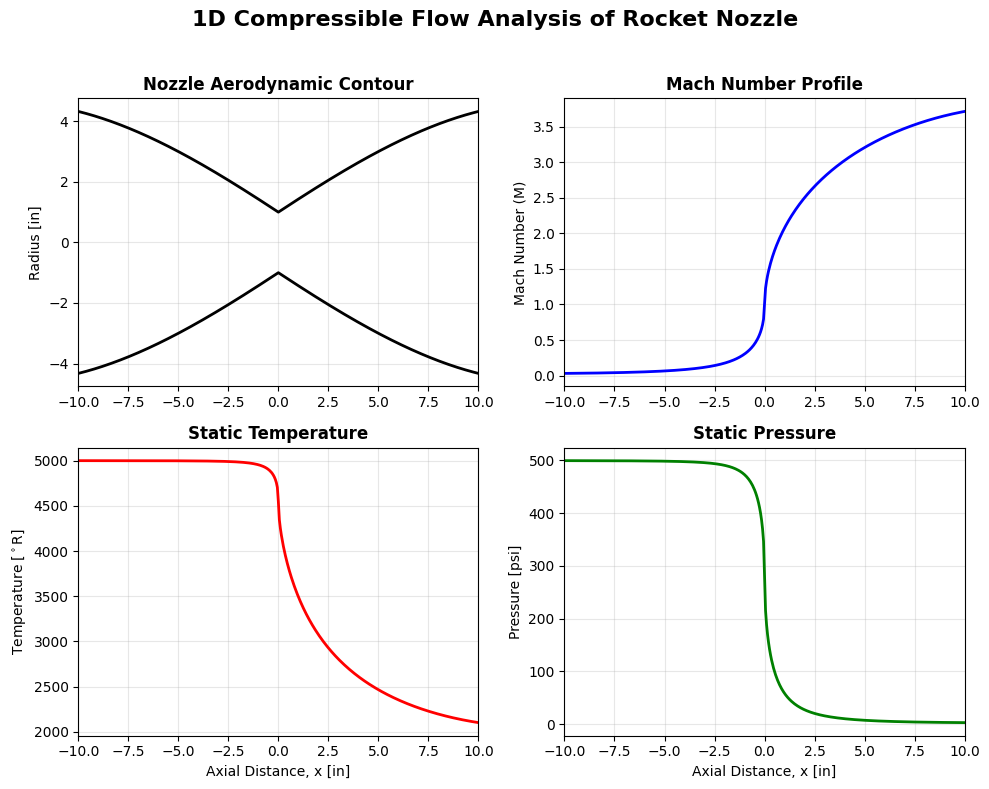

In [4]:
# 1. Create the axial positions and calculate geometry
x_coords = np.linspace(-10, 10, 401)
r_coords = get_radius(x_coords)
r_throat = get_radius(0)
area_ratios = (r_coords / r_throat)**2

# 2. Solve for Mach number at each point
mach_numbers = np.array([
    solve_mach_from_area_ratio(ar, GAMMA, supersonic=(x > 0)) if x != 0 else 1.0
    for x, ar in zip(x_coords, area_ratios)
])

# 3. Calculate flow properties using isentropic relations
pressure_ratio = (1 + (GAMMA - 1) / 2 * mach_numbers**2) ** (GAMMA / (GAMMA - 1))
static_pressures = PC / pressure_ratio

temp_ratio = (1 + (GAMMA - 1) / 2 * mach_numbers**2)
static_temps = TC / temp_ratio

# 4. Plotting the Dashboard
fig, axs = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle('1D Compressible Flow Analysis of Rocket Nozzle', fontsize=16, fontweight='bold')

# Top-Left: Nozzle Contour
axs[0, 0].plot(x_coords, r_coords, color='black', linewidth=2)
axs[0, 0].plot(x_coords, -r_coords, color='black', linewidth=2)
axs[0, 0].set_title('Nozzle Aerodynamic Contour', fontweight='bold')
axs[0, 0].set_ylabel('Radius [in]')
axs[0, 0].grid(True, alpha=0.3)
axs[0, 0].set_xlim([-10, 10])

# Top-Right: Mach Number
axs[0, 1].plot(x_coords, mach_numbers, color='blue', linewidth=2)
axs[0, 1].set_title('Mach Number Profile', fontweight='bold')
axs[0, 1].set_ylabel('Mach Number (M)')
axs[0, 1].grid(True, alpha=0.3)
axs[0, 1].set_xlim([-10, 10])

# Bottom-Left: Temperature
axs[1, 0].plot(x_coords, static_temps, color='red', linewidth=2)
axs[1, 0].set_title('Static Temperature', fontweight='bold')
axs[1, 0].set_ylabel('Temperature [$^\circ$R]')
axs[1, 0].set_xlabel('Axial Distance, x [in]')
axs[1, 0].grid(True, alpha=0.3)
axs[1, 0].set_xlim([-10, 10])

# Bottom-Right: Pressure
axs[1, 1].plot(x_coords, static_pressures, color='green', linewidth=2)
axs[1, 1].set_title('Static Pressure', fontweight='bold')
axs[1, 1].set_ylabel('Pressure [psi]')
axs[1, 1].set_xlabel('Axial Distance, x [in]')
axs[1, 1].grid(True, alpha=0.3)
axs[1, 1].set_xlim([-10, 10])

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()